<a href="https://colab.research.google.com/github/ss48/opencv/blob/master/r_YOLOv8_ONNX_with_OpenCV_DNN_in_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q ultralytics opencv-python-headless matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 53.1 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO

# Load an official YOLOv8 nano detection model
yolo = YOLO("yolov8n.pt")

# Keep class names for labeling detections
CLASS_NAMES = yolo.names

# Export to ONNX at 640x640
yolo.export(format="onnx", imgsz=640, simplify=True, dynamic=False)

onnx_path = "yolov8n.onnx"
print("Exported ONNX:", onnx_path)
print("Classes:", list(CLASS_NAMES.items())[:5], "...")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

PyTorch: starting from 'yolov8n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (6.2 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 166ms
Prepared 4 packages in 1.75s
Installed 4 packages in 319

In [3]:
from google.colab import files

uploaded = files.upload()
print(uploaded.keys())


Saving fruit.jpg to fruit.jpg
dict_keys(['fruit.jpg'])


Raw output shape: (1, 84, 8400)
Detections: 1
Inference time: 0.378 sec
{'class_id': 47, 'confidence': 0.2866969108581543, 'box': [205, 318, 125, 80]}


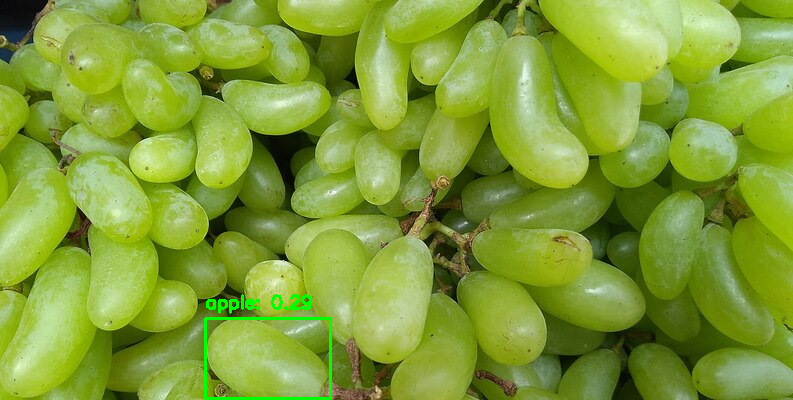

In [4]:
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

image_path = "/content/fruit.jpg"   # change this

# Thresholds
CONF_THRES = 0.25
NMS_THRES = 0.45
INPUT_SIZE = 640

# Load OpenCV DNN model
net = cv2.dnn.readNetFromONNX(onnx_path)

def letterbox(image, new_shape=(640, 640), color=(114, 114, 114)):
    """Resize with unchanged aspect ratio and pad."""
    shape = image.shape[:2]  # (h, w)

    if isinstance(new_shape, int):
        new_shape = (new_shape, new_shape)

    r = min(new_shape[0] / shape[0], new_shape[1] / shape[1])
    new_unpad = (int(round(shape[1] * r)), int(round(shape[0] * r)))

    dw = new_shape[1] - new_unpad[0]
    dh = new_shape[0] - new_unpad[1]
    dw /= 2
    dh /= 2

    if shape[::-1] != new_unpad:
        image = cv2.resize(image, new_unpad, interpolation=cv2.INTER_LINEAR)

    top = int(round(dh - 0.1))
    bottom = int(round(dh + 0.1))
    left = int(round(dw - 0.1))
    right = int(round(dw + 0.1))

    image = cv2.copyMakeBorder(
        image, top, bottom, left, right,
        cv2.BORDER_CONSTANT, value=color
    )

    return image, r, (left, top)

def preprocess(image, input_size=640):
    img_lb, ratio, (pad_x, pad_y) = letterbox(image, (input_size, input_size))
    blob = cv2.dnn.blobFromImage(
        img_lb,
        scalefactor=1/255.0,
        size=(input_size, input_size),
        mean=(0, 0, 0),
        swapRB=True,
        crop=False
    )
    return blob, ratio, pad_x, pad_y, img_lb

def postprocess(image, outputs, ratio, pad_x, pad_y,
                conf_thres=0.25, nms_thres=0.45):
    h0, w0 = image.shape[:2]

    preds = np.squeeze(outputs)

    # Handle both [1, 84, N] and [1, N, 84]
    if preds.ndim == 2:
        if preds.shape[0] < preds.shape[1]:
            preds = preds.T
    elif preds.ndim == 1:
        preds = np.expand_dims(preds, 0)

    boxes = []
    confidences = []
    class_ids = []

    for row in preds:
        scores = row[4:]
        class_id = int(np.argmax(scores))
        confidence = float(scores[class_id])

        if confidence >= conf_thres:
            cx, cy, w, h = row[:4]

            x = (cx - w / 2 - pad_x) / ratio
            y = (cy - h / 2 - pad_y) / ratio
            w = w / ratio
            h = h / ratio

            x = max(0, min(int(x), w0 - 1))
            y = max(0, min(int(y), h0 - 1))
            w = max(1, min(int(w), w0 - x))
            h = max(1, min(int(h), h0 - y))

            boxes.append([x, y, w, h])
            confidences.append(confidence)
            class_ids.append(class_id)

    indices = cv2.dnn.NMSBoxes(boxes, confidences, conf_thres, nms_thres)

    results = []
    if len(indices) > 0:
        for i in indices.flatten():
            results.append({
                "class_id": class_ids[i],
                "confidence": confidences[i],
                "box": boxes[i]
            })
    return results

def draw_detections(image, detections, class_names):
    out = image.copy()
    for det in detections:
        x, y, w, h = det["box"]
        cls_id = det["class_id"]
        conf = det["confidence"]
        label = f'{class_names.get(cls_id, cls_id)}: {conf:.2f}'

        cv2.rectangle(out, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(
            out, label, (x, max(20, y - 10)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2
        )
    return out

# Read image
image = cv2.imread(image_path)
if image is None:
    raise ValueError(f"Could not read image: {image_path}")

blob, ratio, pad_x, pad_y, img_lb = preprocess(image, INPUT_SIZE)

# Inference
net.setInput(blob)
start = time.time()
outputs = net.forward()
elapsed = time.time() - start

# Postprocess
detections = postprocess(image, outputs, ratio, pad_x, pad_y, CONF_THRES, NMS_THRES)

print("Raw output shape:", outputs.shape)
print("Detections:", len(detections))
print(f"Inference time: {elapsed:.3f} sec")

for det in detections[:10]:
    print(det)

# Draw
result = draw_detections(image, detections, CLASS_NAMES)

cv2_imshow(result)


In [8]:
from ultralytics import YOLO

# Load official model
yolo = YOLO("yolov8n.pt")

# Save class names
CLASS_NAMES = yolo.names

# Export to ONNX
yolo.export(format="onnx", imgsz=640, simplify=True, dynamic=False)

# Use the exported ONNX file in OpenCV
onnx_path = "/content/yolov8n.onnx"

print("ONNX path:", onnx_path)
print("First classes:", list(CLASS_NAMES.items())[:5])


Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

PyTorch: starting from 'yolov8n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (6.2 MB)

ONNX: starting export with onnx 1.20.1 opset 20...
ONNX: slimming with onnxslim 0.1.88...
ONNX: export success ✅ 1.6s, saved as 'yolov8n.onnx' (12.3 MB)

Export complete (2.1s)
Results saved to /content
Predict:         yolo predict task=detect model=yolov8n.onnx imgsz=640 
Validate:        yolo val task=detect model=yolov8n.onnx imgsz=640 data=coco.yaml  
Visualize:       https://netron.app
ONNX path: /content/yolov8n.onnx
First classes: [(0, 'person'), (1, 'bicycle'), (2, 'car'), (3, 'motorcycle'), (4, 'airplane')]


In [5]:
cv2.imwrite("/content/yolo_result.jpg", result)
print("Saved to /content/yolo_result.jpg")


Saved to /content/yolo_result.jpg


In [14]:
from google.colab import files

uploaded = files.upload()
print(uploaded.keys())


Saving fruit2.png to fruit2.png
dict_keys(['fruit2.png'])


Output shape: (1, 84, 8400)
Detections found: 2
Inference time: 0.349 sec


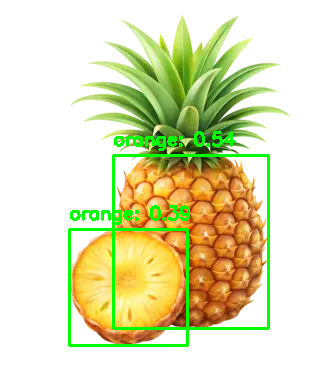

In [16]:
import time
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Change this to your uploaded image name
image_path = "/content/fruit2.png"

CONF_THRES = 0.25
NMS_THRES = 0.45
INPUT_SIZE = 640

# Load ONNX model with OpenCV
net = cv2.dnn.readNetFromONNX("/content/yolov8n.onnx")

def letterbox(image, new_shape=(640, 640), color=(114, 114, 114)):
    shape = image.shape[:2]  # h, w
    r = min(new_shape[0] / shape[0], new_shape[1] / shape[1])

    new_unpad = (int(round(shape[1] * r)), int(round(shape[0] * r)))
    dw = new_shape[1] - new_unpad[0]
    dh = new_shape[0] - new_unpad[1]
    dw /= 2
    dh /= 2

    if shape[::-1] != new_unpad:
        image = cv2.resize(image, new_unpad, interpolation=cv2.INTER_LINEAR)

    top = int(round(dh - 0.1))
    bottom = int(round(dh + 0.1))
    left = int(round(dw - 0.1))
    right = int(round(dw + 0.1))

    image = cv2.copyMakeBorder(
        image, top, bottom, left, right,
        cv2.BORDER_CONSTANT, value=color
    )

    return image, r, (left, top)

def preprocess(image):
    img_lb, ratio, (pad_x, pad_y) = letterbox(image, (INPUT_SIZE, INPUT_SIZE))
    blob = cv2.dnn.blobFromImage(
        img_lb,
        scalefactor=1 / 255.0,
        size=(INPUT_SIZE, INPUT_SIZE),
        swapRB=True,
        crop=False
    )
    return blob, ratio, pad_x, pad_y

def postprocess(image, outputs, ratio, pad_x, pad_y):
    h0, w0 = image.shape[:2]
    preds = np.squeeze(outputs)

    # YOLOv8 ONNX often gives shape (84, 8400), so transpose it
    if preds.ndim == 2 and preds.shape[0] == 84:
        preds = preds.T

    boxes = []
    confidences = []
    class_ids = []

    for row in preds:
        x, y, w, h = row[:4]
        class_scores = row[4:]
        class_id = np.argmax(class_scores)
        confidence = class_scores[class_id]

        if confidence >= CONF_THRES:
            left = int((x - w / 2 - pad_x) / ratio)
            top = int((y - h / 2 - pad_y) / ratio)
            width = int(w / ratio)
            height = int(h / ratio)

            left = max(0, min(left, w0 - 1))
            top = max(0, min(top, h0 - 1))
            width = max(1, min(width, w0 - left))
            height = max(1, min(height, h0 - top))

            boxes.append([left, top, width, height])
            confidences.append(float(confidence))
            class_ids.append(int(class_id))

    indices = cv2.dnn.NMSBoxes(boxes, confidences, CONF_THRES, NMS_THRES)

    detections = []
    if len(indices) > 0:
        for i in indices.flatten():
            detections.append((boxes[i], confidences[i], class_ids[i]))

    return detections

# Read image
image = cv2.imread(image_path)
if image is None:
    raise ValueError(f"Could not read image: {image_path}")

# Run inference
blob, ratio, pad_x, pad_y = preprocess(image)
net.setInput(blob)

start = time.time()
outputs = net.forward()
elapsed = time.time() - start

detections = postprocess(image, outputs, ratio, pad_x, pad_y)

print("Output shape:", outputs.shape)
print("Detections found:", len(detections))
print(f"Inference time: {elapsed:.3f} sec")

# Draw detections
result = image.copy()
for box, conf, class_id in detections:
    x, y, w, h = box
    label = f"{CLASS_NAMES[class_id]}: {conf:.2f}"
    cv2.rectangle(result, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(result, label, (x, max(20, y - 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

cv2_imshow(result)
